# Basecase

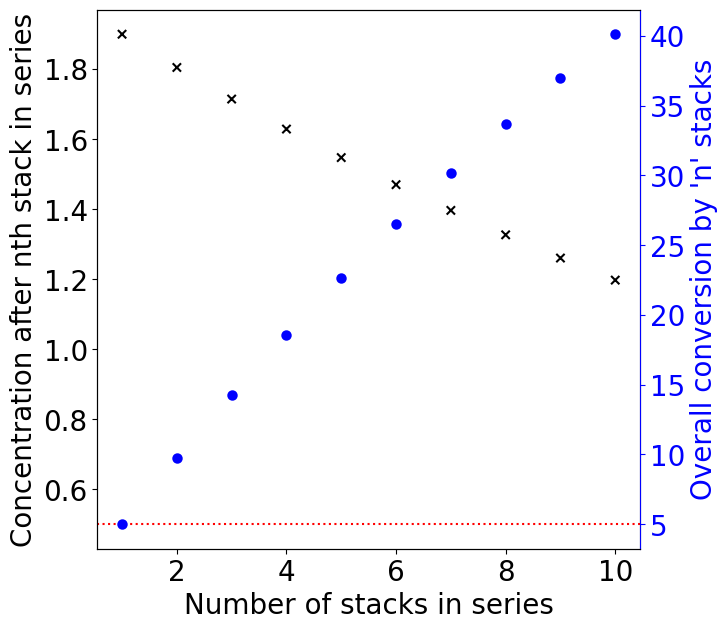

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.5      ### ethylene
FEC2H5OH = 0.2;
J = 0.5         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 120      ### 2M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- concentration variation with Nseries'
C0=120  # 2 M K2CO3 
Xdash = 0.05
stackseries=10
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

stackseries=10
for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 10]+1, Cn[ : 10], ls = '-', linewidth =1.5, c=col[:10], marker ='x', label= "Concentration")
ax2.scatter(stacks[:10]+1, conv[:10], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')

ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

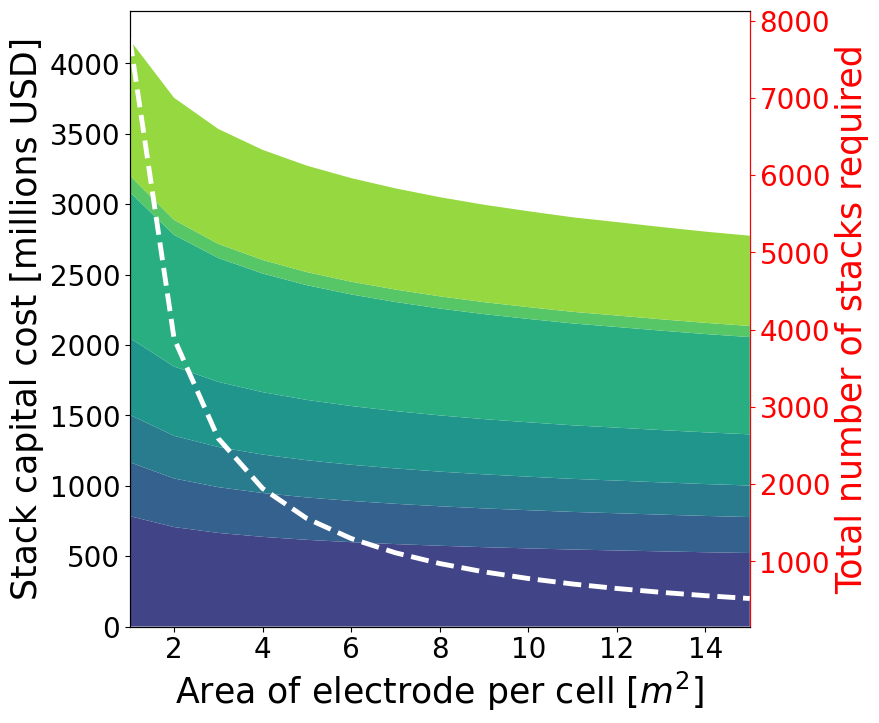

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))
X = 0.35    ### conversion FOR n-stack system

Itot = (2000000* 1000/ 28/ 365/ 86400)* 12 *96485 *1000 /0.5/0.9
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
#ax.set_ylim(0,12000)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
# ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =25)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =25)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =25)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# Optimisitic

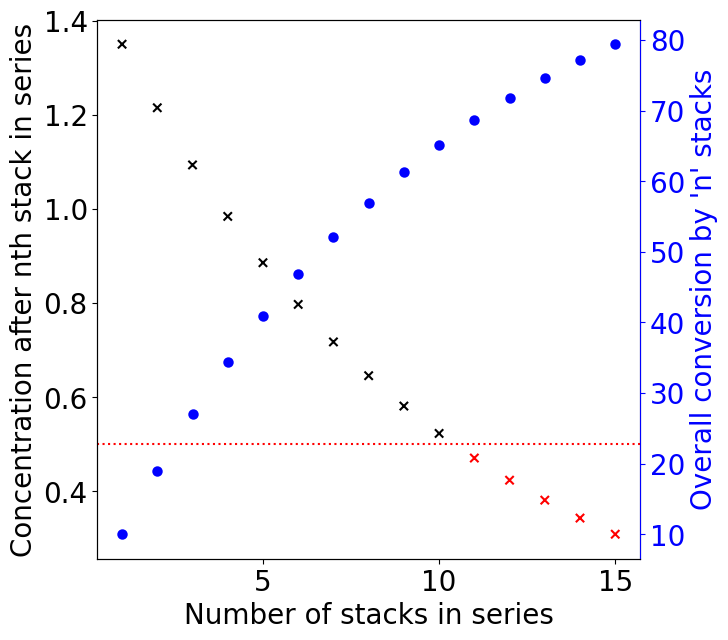

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.65      ### ethylene
FEC2H5OH = 0.25;
J = 1         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 1.5 M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = 6                   ### m2
areaperst = cellperst* areapercel ### m2

X = 0.1
#---------------------------------------------------------------- concentration variation with Nseries'
C0=90  # 1.5 M K2CO3 
Xdash = X
stackseries=15
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 15]+1, Cn[ : 15], ls = '-', linewidth =1.5, c=col[:15], marker ='x', label= "Concentration")
ax2.scatter(stacks[:15]+1, conv[:15], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

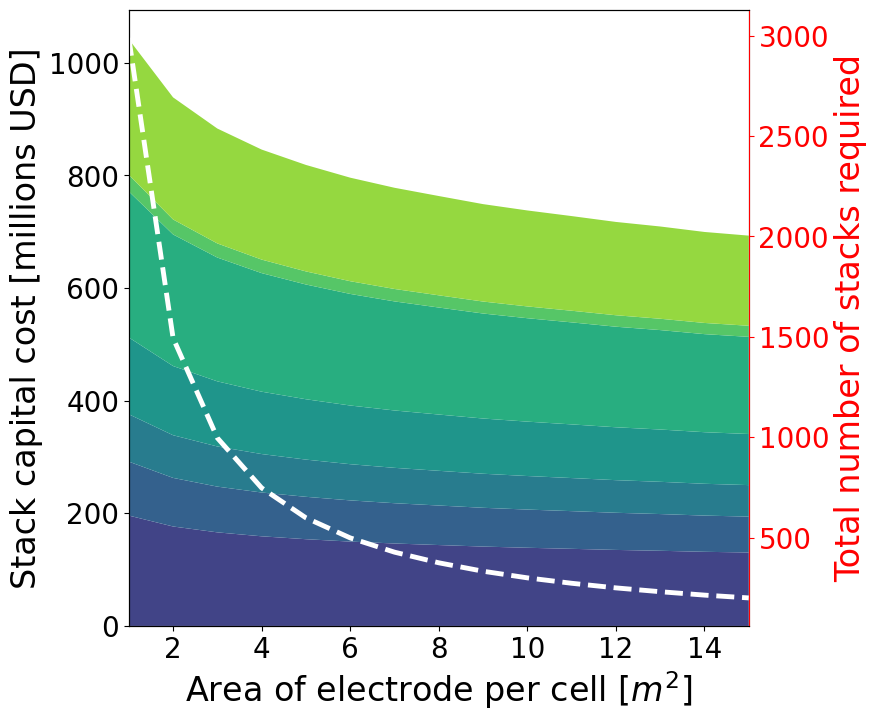

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.65      ### ethylene
FEC2H5OH = 0.25;
J = 1         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 2M initial conc for [H]CO3
X = 0.65    ### conversion FOR n-stack system

plt.rcParams.update({'font.size': 20})

Itot = (2000000* 1000/ 28/ 365/ 86400)* 12 *96485 *1000 /0.65/0.9
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))


for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]*0.65
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
# ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =24)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =24)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =24)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# pessimistic

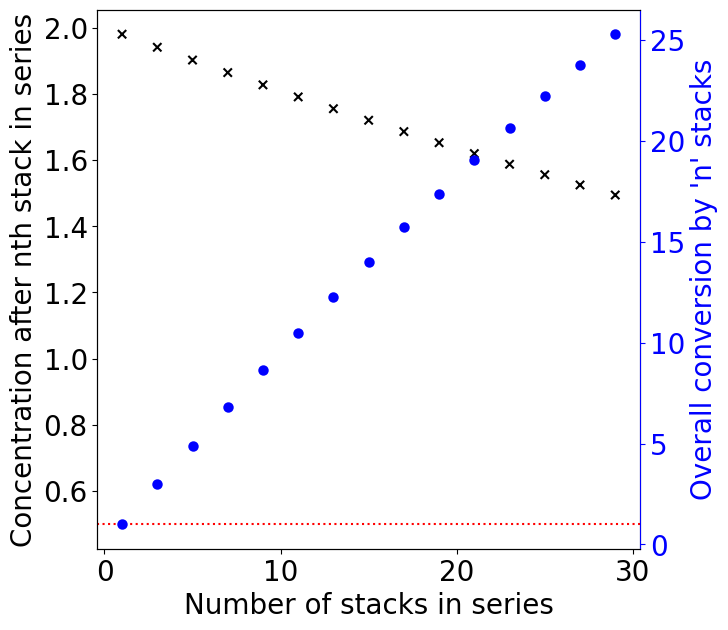

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.34      ### ethylene
FEC2H5OH = 0.13;
J = 0.3         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 120      ### 2M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- concentration variation with Nseries'
C0=120  # 2 M K2CO3 
Xdash = 0.01
stackseries=30
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : :2]+1, Cn[ : :2], ls = '-', linewidth =1.5, c=col[::2], marker ='x', label= "Concentration")
ax2.scatter(stacks[::2]+1, conv[::2], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

In [6]:
stacks[:10:2]

array([0., 2., 4., 6., 8.])

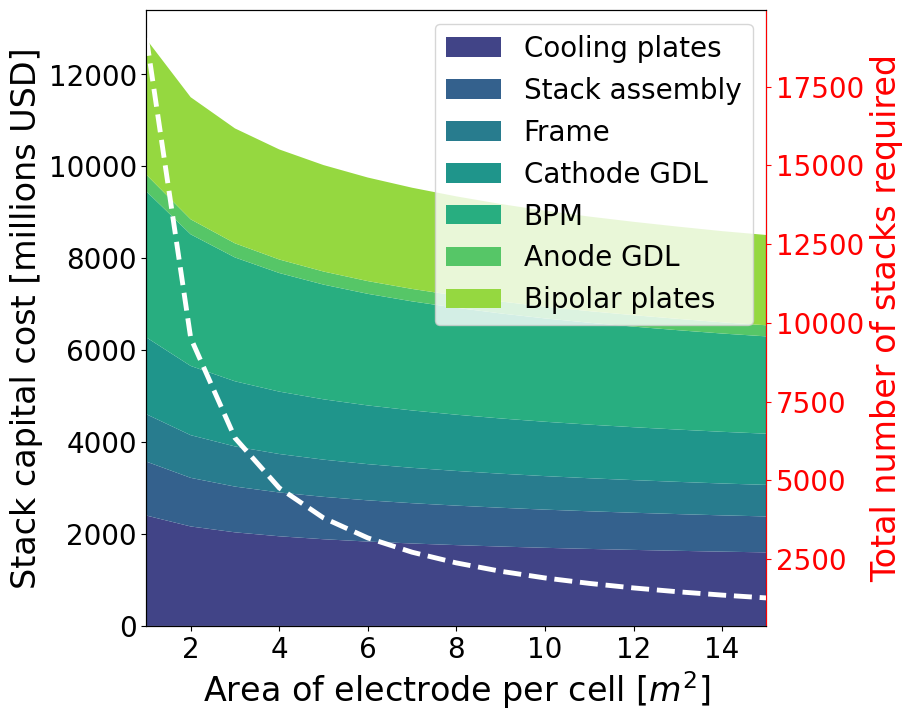

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.34      ### ethylene
FEC2H5OH = 0.13;
J = 0.3         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 2M initial conc for [H]CO3
X = 0.2    ### conversion FOR n-stack system

plt.rcParams.update({'font.size': 20})

Itot = (2000000* 1000/ 28/ 365/ 86400)* 12 *96485 *1000 /0.34/0.9
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))


for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]*1.25
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =24)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =24)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =24)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# Econometrics

In [62]:
soln = [1.45809720090480,2.05808850234782,2.62822155369402,5.72678633424794,10.3225376660287,40.5425424339952,73.0779702481148,159.233882228562,287.019220043619,517.352409685023,\
1.12725007235987,1.59110134204699,2.03186929838484,4.42735937334260,7.98031936673882,31.3433040431149,56.4963345372184,123.103182114954,221.893599659935,399.963418687798,\
8.90025206924155,11.8670027589887,14.8337534487359,35.6010082769662,68.2352658641853,332.276077251685,661.585403813622,1649.51338349943,3296.06001630912,6589.15328192850,\
0.00997136890709270,0.0140744798684349,0.0179734016807611,0.0391633007425350,0.0705918858231534,0.277254936632458,0.499752279802279,1.08893959965376,1.96281463588640,3.53797519722386,\
4.49116089083582,5.96516546399314,7.29591239200559,13.8559917628473,22.5091250265300,69.4444618078371,112.812861034170,214.247922569010,348.046777042047,565.403657392934,\
0.0189132911653500,0.0266959068742529,0.0340912248245301,0.0742833724076605,0.133895847493393,0.525886003458402,0.947910007794891,2.06545679952544,3.72298779214998,6.71068893993928,\
4.79244342189930,6.38992456253240,7.98740570316550,19.1697736875972,36.7420662345613,178.917887750907,356.238294361181,888.199514192003,1774.80154724337,3548.00561334611,\
7.81400000000000,6.50400000000000,5.80800000000000,4.57800000000000,3.97400000000000,3.24400000000000,3.05400000000000,2.86600000000000,2.75600000000000,2.66600000000000]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


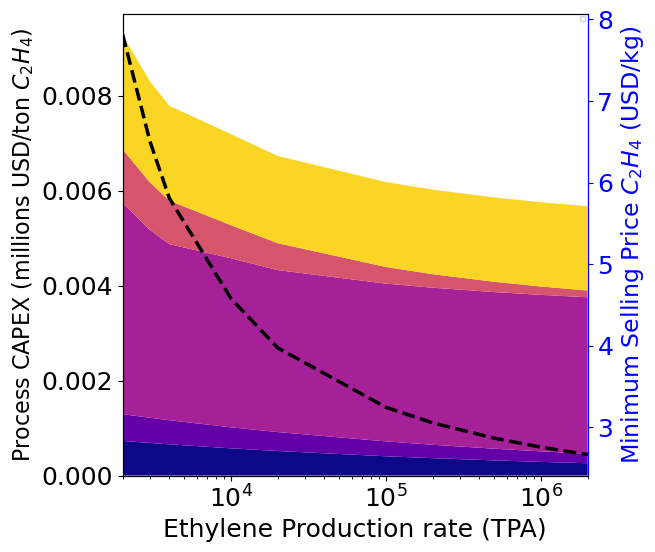

In [66]:
#----------------------------------------------------------------------------------------- base case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 110 # for example, max percentile of color ramp
pct_min = 0 # for example, min percentile of color ramp
ramp = plt.cm.plasma # for example


plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(6,6))
ax2 = ax.twinx()

prodrate = [2000, 3000, 4000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

soln1 = np.resize(soln,(8,len(prodrate)))

for pp in range(len(prodrate)):
    soln1[:7,pp] = soln1[:7,pp]/prodrate[pp]

CCU= soln1[0,:]
GO= soln1[1,:]
elec=soln1[2,:]
zhf_sep= soln1[3,:]
distl = soln1[4,:]/2
bop= soln1[6,:]
breakeven = soln1[7,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, colors =clr_lst)
ax.margins(x=0)
ax.legend(fontsize=4)
ax.set_xscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =2.5, c='black')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =17)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =18)
ax.set_ylabel("Process CAPEX (millions USD/ton $C_{2}H_{4}$)", fontsize =16)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
plt.show()

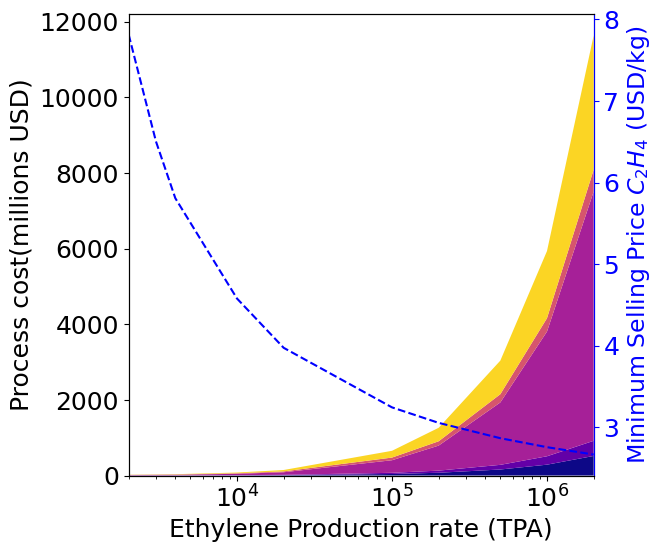

In [34]:
#----------------------------------------------------------------------------------------- base case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 110 # for example, max percentile of color ramp
pct_min = 0 # for example, min percentile of color ramp
ramp = plt.cm.plasma # for example


plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(6,6))
ax2 = ax.twinx()

prodrate = [2000, 3000, 4000, 5000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

soln = np.resize(soln,(8,len(prodrate)))

CCU= soln[0,:]
GO= soln[1,:]
elec=soln[2,:]
zhf_sep= soln[3,:]
distl = soln[4,:]
pervap= soln[5,:]
bop= soln[6,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven = soln[7,:]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, labels=source, colors =clr_lst)
ax.margins(x=0)
#ax.legend(fontsize=4)
ax.set_xscale('log')
#ax.legend(loc='center left')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =17)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =18)
ax.set_ylabel("Process cost(millions USD)", fontsize =18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
plt.show()

# Pessimistic

In [74]:
soln = [20.2396318402346,28.5680224585105,36.4819551181687,44.1013227632784,79.4926750843084,143.285620387811,562.765042153541,1014.38450916416,2210.30199550309,3984.07139191361,7181.29237007343,\
99.5384410534474,140.497437994259,179.418132093961,216.890156446678,390.944707666607,704.678197279570,2767.67657719863,4988.73959111486,10870.2577510497,19593.6496536649,35317.5716292001,\
20.6460427362102,31.7631426710925,41.2920854724203,50.8210282737481,101.642056547496,201.695955961438,1008.47977980719,2016.95955961438,5042.39889903594,10083.2096409383,20164.8311247431,\
0.0303713263239423,0.0428688001523982,0.0547443437991150,0.0661778670449130,0.119285666577652,0.215012524371900,0.844477847911004,1.52217210218878,3.31675021115934,5.97844532434384,10.7761532285169,\
49.1667395492138,65.3033244332368,79.8716040397437,93.3747421290916,151.687716107000,246.417421811431,760.239468109066,1235.01265955236,2345.46747799771,3810.22315915852,6189.72578335706,\
0.165159260542911,0.233120518281432,0.297699719937522,0.359875214828161,0.648675407692103,1.16923802253355,4.59227020309286,8.27757128994275,18.0364863370746,32.5107833103248,58.6007169965414,\
11.1170999348824,17.1032306690498,22.2341998697648,27.3651690704797,54.7303381409595,108.605514748466,543.027573742332,1086.05514748466,2715.13786871166,5429.42057588987,10857.9859902463,\
79.0740000000000,74.3480000000000,71.1080000000000,68.8160000000000,62.8740000000000,57.9400000000000,49.4380000000000,46.6720000000000,43.6260000000000,41.7000000000000,40.0420000000000]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


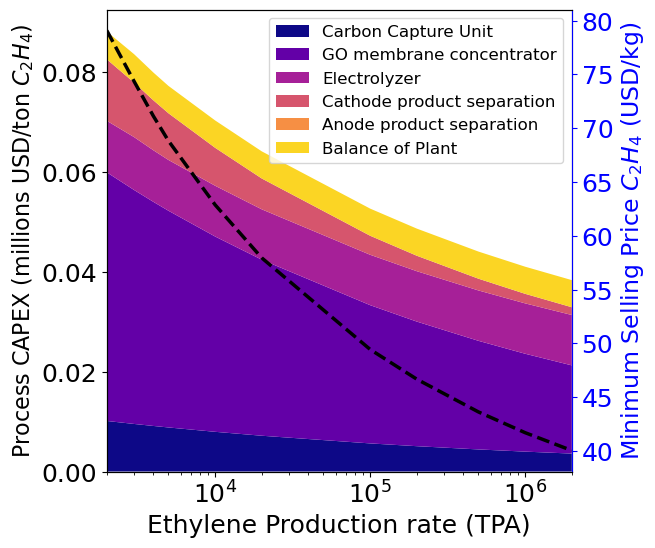

In [75]:
#----------------------------------------------------------------------------------------- pessimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 110 # for example, max percentile of color ramp
pct_min = 0 # for example, min percentile of color ramp
ramp = plt.cm.plasma # for example


plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(6,6))
ax2 = ax.twinx()

prodrate = [2000, 3000, 4000, 5000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

soln1 = np.resize(soln,(8,len(prodrate)))

for pp in range(len(prodrate)):
    soln1[:7,pp] = soln1[:7,pp]/prodrate[pp]

CCU= soln1[0,:]
GO= soln1[1,:]
elec=soln1[2,:]
zhf_sep= soln1[3,:]
distl = soln1[4,:]/2
bop= soln1[6,:]
breakeven = soln1[7,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, colors =clr_lst)
ax.margins(x=0)
ax.legend(fontsize=4)
ax.set_xscale('log')
ax.legend(source, fontsize = 12)
ax2.plot(prodrate, breakeven, ls = '--', linewidth =2.5, c='black')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =17)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =18)
ax.set_ylabel("Process CAPEX (millions USD/ton $C_{2}H_{4}$)", fontsize =16)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
plt.show()

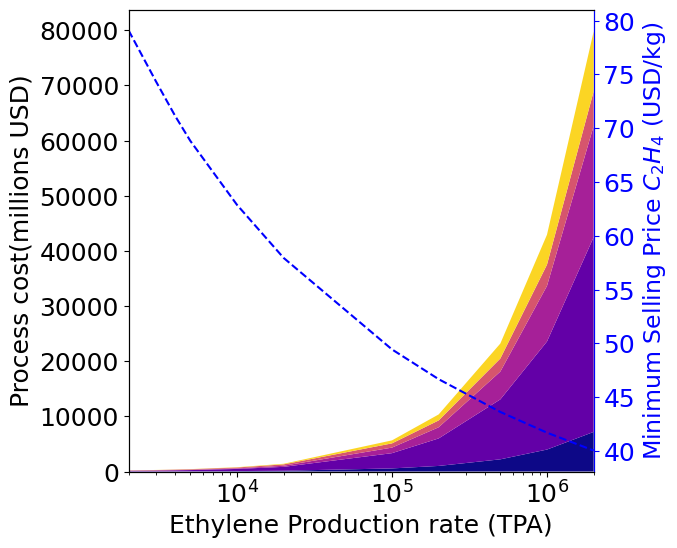

In [28]:
#----------------------------------------------------------------------------------------- pessimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 110 # for example, max percentile of color ramp
pct_min = 0 # for example, min percentile of color ramp
ramp = plt.cm.plasma # for example


plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(6,6))
ax2 = ax.twinx()

prodrate = [2000, 3000, 4000, 5000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

soln = np.resize(soln,(8,len(prodrate)))

CCU= soln[0,:]
GO= soln[1,:]
elec=soln[2,:]
zhf_sep= soln[3,:]
distl = soln[4,:]
pervap= soln[5,:]
bop= soln[6,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven = soln[7,:]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, labels=source, colors =clr_lst)
ax.margins(x=0)
#ax.legend(fontsize=4)
ax.set_xscale('log')
#ax.legend(loc='center left')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =17)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =18)
ax.set_ylabel("Process cost(millions USD)", fontsize =18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
plt.show()

# Optimistic

In [76]:
soln = [0.832053703997145,1.17443484595527,1.49977757128896,1.81301069337702,3.26795345224884,5.89048912125986,23.1353387008316,41.7014694135654,90.8657813950292,163.785655035529,295.223794739577,\
0.445623558244425,0.628992855228759,0.803236876036144,0.970995348541387,1.75022001413178,3.15477319481400,12.3906088074934,22.3340838395665,48.6650472600407,87.7187927121791,158.113205023030,\
4.01067814737848,4.01067814737848,4.01067814737848,4.01067814737848,8.02135629475695,16.0427125895139,80.2135629475695,160.427125895139,401.067814737847,798.124951328317,1592.23922450925,\
0.00193818817744029,0.00273573174744525,0.00349358598308981,0.00422323207576061,0.00761237972398429,0.0137213214956203,0.0538915213472596,0.0971395170900383,0.211663000101642,0.381522753518402,0.687695116210036,\
3.49304804155859,4.63947073997976,5.67447328468685,6.63380291464288,10.7766446287473,17.5067108487591,54.0111670926607,87.7413998020214,166.633595306002,270.697074201510,439.748694413596,\
0.0176671397994879,0.0249369776364254,0.0318450358345973,0.0384959687385373,0.0693890192685176,0.125073771431727,0.491236636736968,0.885454492221161,1.92936880778695,3.47768906112978,6.26853775031968,\
2.15959592551149,2.15959592551149,2.15959592551149,2.15959592551149,4.31919185102297,8.63838370204595,43.1919185102297,86.3838370204595,215.959592551149,429.759589176786,857.359582428060,\
5.48600000000000,4.14200000000000,3.44000000000000,3.00200000000000,2.30400000000000,1.87000000000000,1.33400000000000,1.20000000000000,1.06800000000000,0.990000000000000,0.926000000000000]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


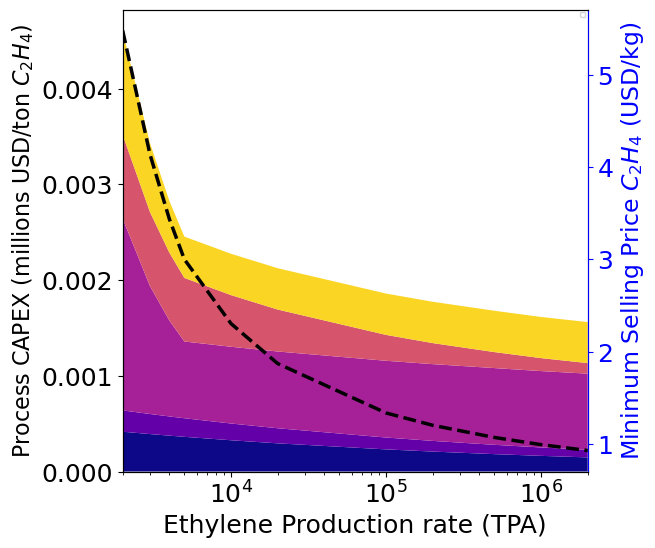

In [77]:
#----------------------------------------------------------------------------------------- optimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 110 # for example, max percentile of color ramp
pct_min = 0 # for example, min percentile of color ramp
ramp = plt.cm.plasma # for example


plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(6,6))
ax2 = ax.twinx()

prodrate = [2000, 3000, 4000, 5000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

soln1 = np.resize(soln,(8,len(prodrate)))

for pp in range(len(prodrate)):
    soln1[:7,pp] = soln1[:7,pp]/prodrate[pp]

CCU= soln1[0,:]
GO= soln1[1,:]
elec=soln1[2,:]
zhf_sep= soln1[3,:]
distl = soln1[4,:]/2
bop= soln1[6,:]
breakeven = soln1[7,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, colors =clr_lst)
ax.margins(x=0)
ax.legend(fontsize=4)
ax.set_xscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =2.5, c='black')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =17)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =18)
ax.set_ylabel("Process CAPEX (millions USD/ton $C_{2}H_{4}$)", fontsize =16)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
plt.show()

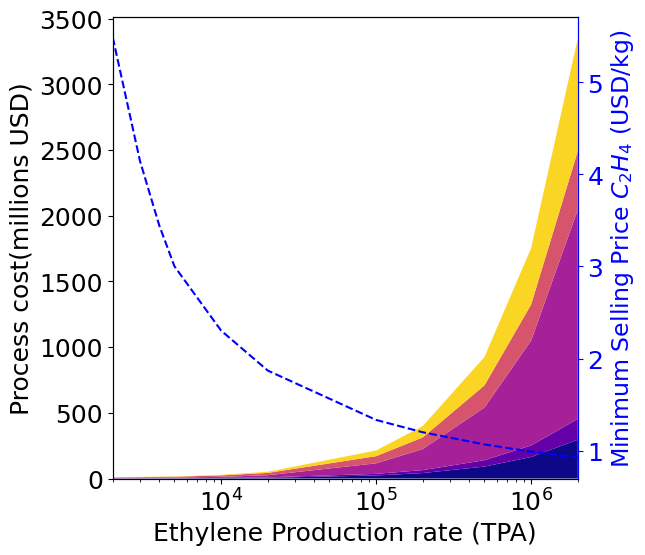

In [25]:
#----------------------------------------------------------------------------------------- optimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 110 # for example, max percentile of color ramp
pct_min = 0 # for example, min percentile of color ramp
ramp = plt.cm.plasma # for example


plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(6,6))
ax2 = ax.twinx()

prodrate = [2000, 3000, 4000, 5000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

soln = np.resize(soln,(8,len(prodrate)))

CCU= soln[0,:]
GO= soln[1,:]
elec=soln[2,:]
zhf_sep= soln[3,:]
distl = soln[4,:]
pervap= soln[5,:]
bop= soln[6,:]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven = soln[7,:]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, labels=source, colors =clr_lst)
ax.margins(x=0)
#ax.legend(fontsize=4)
ax.set_xscale('log')
#ax.legend(loc='center left')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =17)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =18)
ax.set_ylabel("Process cost(millions USD)", fontsize =18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
plt.show()